# **ETAPAS**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report


# **A. Importación de datos**


In [ ]:

!pip install gdown
import gdown

url = 'https://drive.google.com/uc?id=1NpIuiDz-28NIWUpoIE2oev5R6ftg7_AX'
output = 'pruebas-saber-pro-colombia2024.zip'
gdown.download(url, output)


Downloading...
From: https://drive.google.com/uc?id=1NpIuiDz-28NIWUpoIE2oev5R6ftg7_AX
To: /content/pruebas-saber-pro-colombia2024.zip
100%|██████████| 22.2M/22.2M [00:00<00:00, 48.4MB/s]


'pruebas-saber-pro-colombia2024.zip'

In [ ]:
import zipfile
import pandas as pd
import os

# Descomprimir el archivo
with zipfile.ZipFile("/content/pruebas-saber-pro-colombia2024.zip", 'r') as zip_ref:
    zip_ref.extractall('/content/data')

# Navigate to the directory where the files are extracted
os.chdir('/content/data')


train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_df=pd.read_csv('submission.csv')

# Mostrar los primeros registros para verificar la carga
print(train_df.head())
print(test_df.head())
print(submission_df.head())


       ID  PERIODO         ESTU_PRGM_ACADEMICO ESTU_PRGM_DEPARTAMENTO  \
0  904256    20212                  ENFERMERIA                 BOGOTÁ   
1  645256    20212                     DERECHO              ATLANTICO   
2  308367    20203       MERCADEO Y PUBLICIDAD                 BOGOTÁ   
3  470353    20195  ADMINISTRACION DE EMPRESAS              SANTANDER   
4  989032    20212                  PSICOLOGIA              ANTIOQUIA   

             ESTU_VALORMATRICULAUNIVERSIDAD ESTU_HORASSEMANATRABAJA  \
0  Entre 5.5 millones y menos de 7 millones       Menos de 10 horas   
1  Entre 2.5 millones y menos de 4 millones                       0   
2  Entre 2.5 millones y menos de 4 millones         Más de 30 horas   
3  Entre 4 millones y menos de 5.5 millones                       0   
4  Entre 2.5 millones y menos de 4 millones     Entre 21 y 30 horas   

  FAMI_ESTRATOVIVIENDA FAMI_TIENEINTERNET                 FAMI_EDUCACIONPADRE  \
0            Estrato 3                 Si    Técnica 

Se extraen los datos de la plataforma Kaggle mediante el uso de la API de Kaggle. Este permite extraer los datos en un archivo .zip mediante el uso de un Token proporcionado por la plataforma

Se extraen los datos del archivo .zip que se genero anteriormente. Estos datos son train.csv, test.csv y submission.csv que son almacenados en train_df, test_df y ssubmission_df

# **B. Limpieza de datos**


In [ ]:
def prepareDataFrame(df):

  if "ESTU_PRIVADO_LIBERTAD" in df:
    df = df.drop(columns=['ESTU_PRGM_ACADEMICO',
                          #'ESTU_PRGM_DEPARTAMENTO',
                          'FAMI_TIENEINTERNET.1',
                          'ESTU_PRIVADO_LIBERTAD',
                          #'FAMI_EDUCACIONPADRE',
                          #'FAMI_EDUCACIONMADRE',
                          #'FAMI_TIENELAVADORA',
                          #'FAMI_TIENEAUTOMOVIL'
                          ])
  return df

def handleMissingValues(df):
    # Imputar los valores faltantes en la columna PERIODO con la mediana
    median_periodo = df['PERIODO'].median()
    df['PERIODO'].fillna(median_periodo, inplace=True)

    # Lista de columnas categóricas
    categorical_features = [
        #'ESTU_PRGM_ACADEMICO',
        'ESTU_PRGM_DEPARTAMENTO',
        'ESTU_VALORMATRICULAUNIVERSIDAD',
        'ESTU_HORASSEMANATRABAJA',
        'FAMI_ESTRATOVIVIENDA',
        'FAMI_TIENEINTERNET',
        'FAMI_EDUCACIONPADRE',
        'FAMI_TIENELAVADORA',
        'FAMI_TIENEAUTOMOVIL',
        'ESTU_PAGOMATRICULAPROPIO',
        'FAMI_TIENECOMPUTADOR',
        'FAMI_EDUCACIONMADRE'
    ]

    # Imputar valores faltantes en las columnas categóricas con la moda
    for col in categorical_features:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)

    return df

La funcion prepareDataFrame permite eliminar las columnas seleccionadas. Estas pueden ser seleccionadas debido a que son datos repetidos o que se considera que no son necesarias para la prediccion del modelo.


Por otro lado, la funcion handleMissingValues permite rellenar los espacios vacios de cada columna. En este caso, se llenan con la moda de esa columna

In [ ]:
# Aplicar las funciones a los DataFrames de entrenamiento y prueba
print(train_df.isnull().sum())
train_df = prepareDataFrame(train_df)
train_df = handleMissingValues(train_df)
print(train_df.isnull().sum())
test_df = prepareDataFrame(test_df)
test_df = handleMissingValues(test_df)


ID                                    0
PERIODO                               0
ESTU_PRGM_ACADEMICO                   0
ESTU_PRGM_DEPARTAMENTO                0
ESTU_VALORMATRICULAUNIVERSIDAD     6287
ESTU_HORASSEMANATRABAJA           30857
FAMI_ESTRATOVIVIENDA              32137
FAMI_TIENEINTERNET                26629
FAMI_EDUCACIONPADRE               23178
FAMI_TIENELAVADORA                39773
FAMI_TIENEAUTOMOVIL               43623
ESTU_PRIVADO_LIBERTAD                 0
ESTU_PAGOMATRICULAPROPIO           6498
FAMI_TIENECOMPUTADOR              38103
FAMI_TIENEINTERNET.1              26629
FAMI_EDUCACIONMADRE               23664
RENDIMIENTO_GLOBAL                    0
dtype: int64
ID                                0
PERIODO                           0
ESTU_PRGM_DEPARTAMENTO            0
ESTU_VALORMATRICULAUNIVERSIDAD    0
ESTU_HORASSEMANATRABAJA           0
FAMI_ESTRATOVIVIENDA              0
FAMI_TIENEINTERNET                0
FAMI_EDUCACIONPADRE               0
FAMI_TIENELAVADORA 

En esta seccion se eliminan las columnas no deseadas. Posteriormente se rellenan las columnas que permanecieron en cada dataframe.

Los print nos permiten ver la cantidad de valores Nan en cada columna antes y despues de ejecutar la funcion de prepareDataFrame(df) y la funcion de handleMissingValues(df)

**Distribucion de los datos**

In [ ]:
import pandas as pd

for column in train_df.columns:
    print(f"Distribución de la columna '{column}':")
    print(train_df[column].value_counts())
    print("\n" + "="*50 + "\n")


Distribución de la columna 'ID':
ID
904256    1
915348    1
373660    1
691058    1
790510    1
         ..
190471    1
882806    1
297614    1
540154    1
933374    1
Name: count, Length: 692500, dtype: int64


Distribución de la columna 'PERIODO':
PERIODO
20195    180873
20203    171838
20212    171412
20183    164818
20194      1472
20213      1178
20202       490
20184       254
20196       165
Name: count, dtype: int64


Distribución de la columna 'ESTU_PRGM_DEPARTAMENTO':
ESTU_PRGM_DEPARTAMENTO
BOGOTÁ             282159
ANTIOQUIA           83607
VALLE               44588
ATLANTICO           41020
SANTANDER           28828
NORTE SANTANDER     22588
BOLIVAR             20629
BOYACA              14048
CUNDINAMARCA        14018
NARIÑO              13454
RISARALDA           12679
CORDOBA             12188
TOLIMA              11921
CALDAS              11640
CAUCA               11471
HUILA                9995
MAGDALENA            9512
SUCRE                8674
CESAR                8279


En esta seccion imprimimos la distribucion de los datos en cada columna para poder apreciar las posibles respuestas

# **C. Exploración de datos**


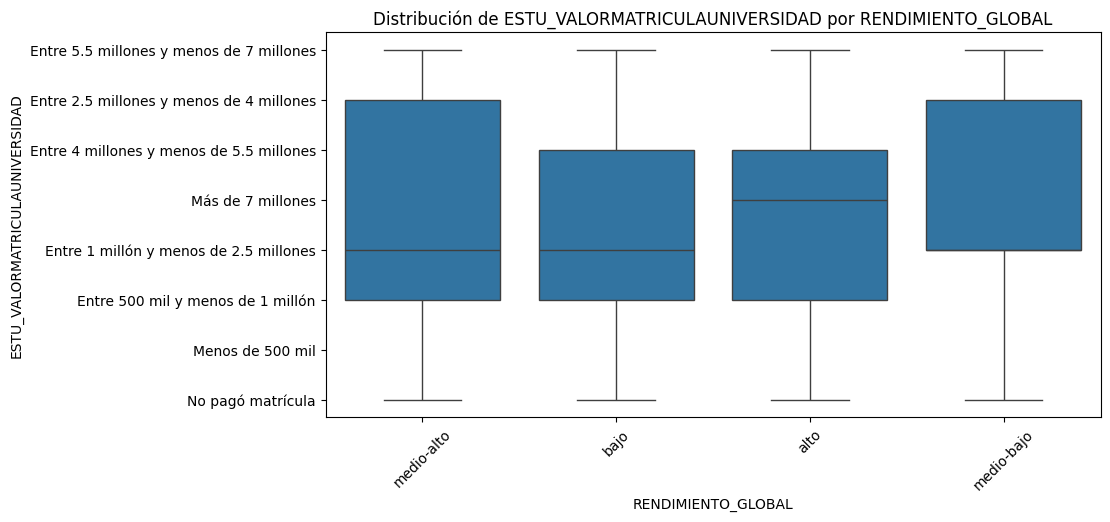

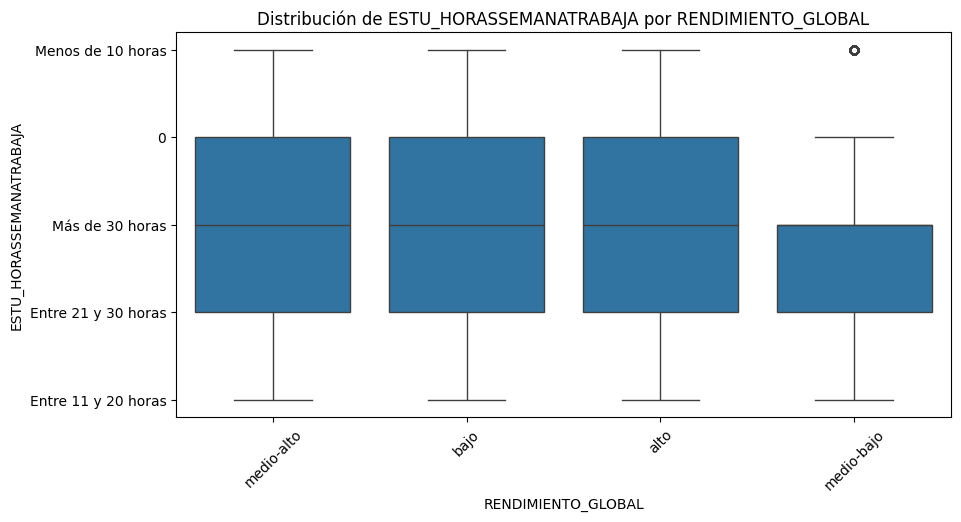

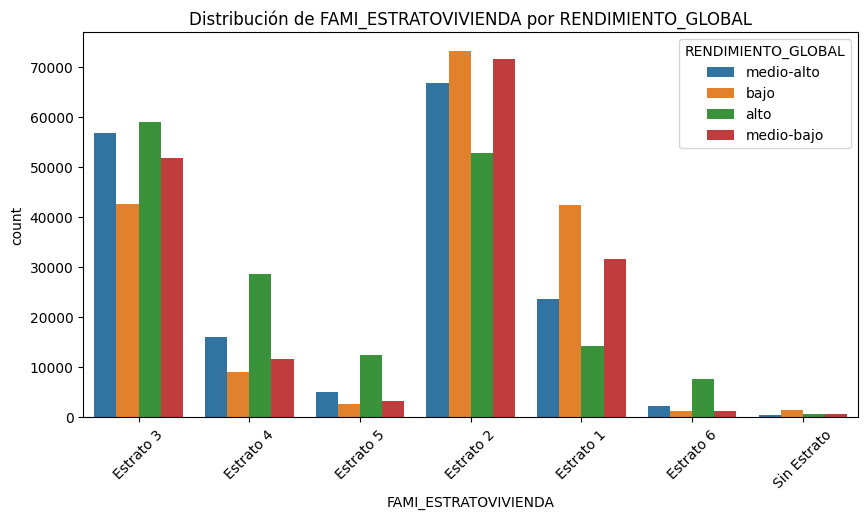

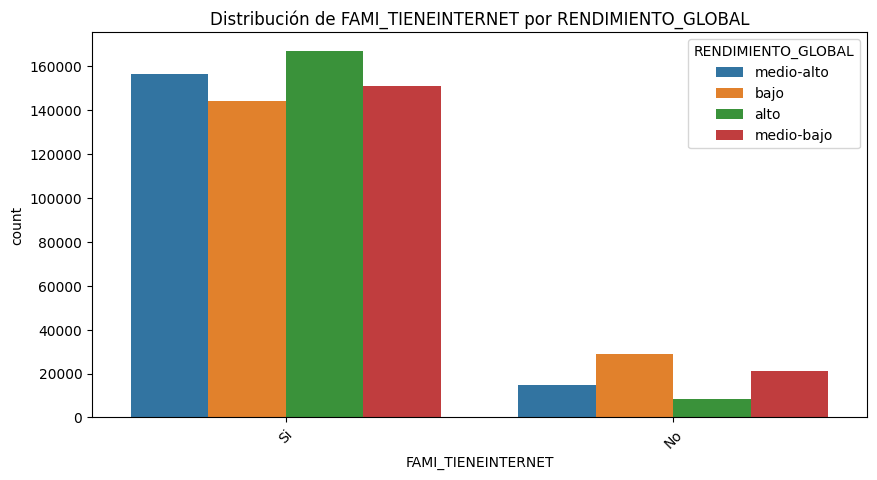

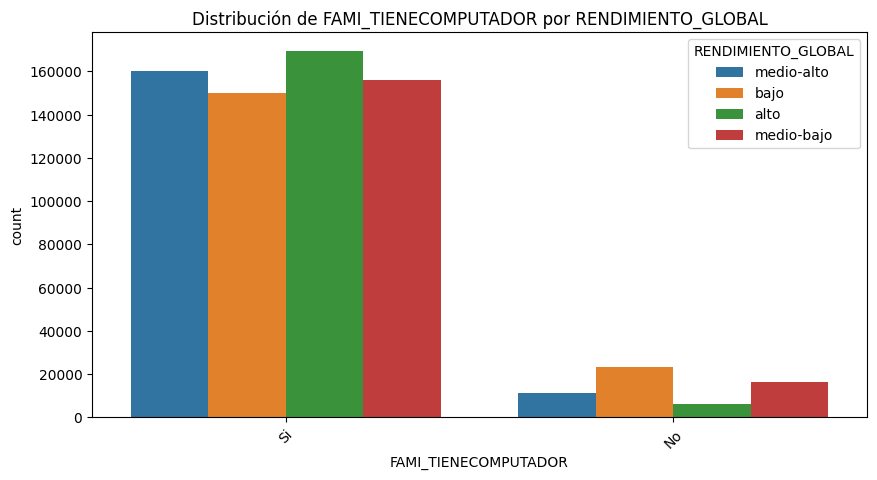

In [ ]:
# Visualización de algunas variables numéricas comparando con RENDIMIENTO_GLOBAL
for col in [#'PERIODO',  'ESTU_PRGM_DEPARTAMENTO',
            'ESTU_VALORMATRICULAUNIVERSIDAD', 'ESTU_HORASSEMANATRABAJA']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='RENDIMIENTO_GLOBAL', y=col, data=train_df)
    plt.title(f'Distribución de {col} por RENDIMIENTO_GLOBAL')
    plt.xticks(rotation=45)
    plt.show()

# Visualización de algunas variables categóricas comparando con RENDIMIENTO_GLOBAL
for col in ['FAMI_ESTRATOVIVIENDA', 'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR']:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='RENDIMIENTO_GLOBAL', data=train_df)
    plt.title(f'Distribución de {col} por RENDIMIENTO_GLOBAL')
    plt.xticks(rotation=45)
    plt.show()


En esta seccion podemos apreciar algunas graficas para representar la relacion entre algunas de las columnas y el rendimiento global de la persona. En este caso tenemos graficas de 'ESTU_VALORMATRICULAUNIVERSIDAD', 'ESTU_HORASSEMANATRABAJA', 'FAMI_ESTRATOVIVIENDA', 'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR'. Estas son algunas de las que se seleccionaron para el proceso de prediccion.


Se puede apreciar que la mayor parte de la gente de los datos pertenenece a los estratos 1, 2 y 3. Ademas de esto, se puede apreciar que en los estratos 1 y 2 prevalecen los resultados bajo y medio bajo y del estrato 3 en adelante prevalece el resultado por encima del bajo y medio bajo

Ademas de esto, se puede apreciar que la mayor parte posee computador e internet



# **D. Modelos**


In [ ]:
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

if 'RENDIMIENTO_GLOBAL' in categorical_features:
    categorical_features.remove('RENDIMIENTO_GLOBAL')

# One-hot encoding para variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
train_encoded = pd.DataFrame(encoder.fit_transform(train_df[categorical_features]))
train_df = train_df.drop(columns=categorical_features)
print(train_df.head())
print(categorical_features)
print(train_encoded)

test_encoded = pd.DataFrame(encoder.transform(test_df[categorical_features]))
test_df = test_df.drop(columns=categorical_features)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


       ID  PERIODO RENDIMIENTO_GLOBAL
0  904256    20212         medio-alto
1  645256    20212               bajo
2  308367    20203               bajo
3  470353    20195               alto
4  989032    20212         medio-bajo
['ESTU_PRGM_DEPARTAMENTO', 'ESTU_VALORMATRICULAUNIVERSIDAD', 'ESTU_HORASSEMANATRABAJA', 'FAMI_ESTRATOVIVIENDA', 'FAMI_TIENEINTERNET', 'FAMI_EDUCACIONPADRE', 'FAMI_TIENELAVADORA', 'FAMI_TIENEAUTOMOVIL', 'ESTU_PAGOMATRICULAPROPIO', 'FAMI_TIENECOMPUTADOR', 'FAMI_EDUCACIONMADRE']
         0    1    2    3    4    5    6    7    8    9   ...   75   76   77  \
0       0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1       0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2       0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4       0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
...     ...  ..

En esta seccion se realiza el proceso de OneHotEncoder que nos permite codificar las características categóricas como un arreglo numérico one-hot, esto nos sera util para el proceso de prediccion. Estos datos los almacenaremos en train_encoded y quitaremos las columnas de train_df. Ademas de esto, se muestran el estado actual de train_df, las categorias que se codificaron y el resultado del proceso OneHotEncoder.

In [ ]:
# Dividir los datos de entrenamiento en entrenamiento y validación
X = train_encoded
y = train_df['RENDIMIENTO_GLOBAL']

print(y[:5])
# Convertir la variable objetivo en categorías numéricas
y = pd.Categorical(y).codes
print(y[:5])  # Imprime los primeros 5 valores de los códigos


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarizar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(test_encoded)



0    medio-alto
1          bajo
2          bajo
3          alto
4    medio-bajo
Name: RENDIMIENTO_GLOBAL, dtype: object
[2 1 1 0 3]


En esta seccion se realiza la division entre los datos de entrenamiento y validacion. En este punto se uso train_encoded y train_df debido a que mp se hallo un metodo que permita hacer una sola matriz con todas las columnas, esto debido a limitaciones de RAM. Posteriormente, se convierte la variable objetivo en categoria numerica. Se hizo un print para ver que numero correspondia a cada categoria y quedo de la siguiente forma

    0: 'alto',
    1: 'bajo',
    2: 'medio-alto',
    3: 'medio-bajo'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="Adamax", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/20
17313/17313 [==============================] - 52s 3ms/step - loss: 1.2773 - accuracy: 0.3871 - val_loss: 1.2533 - val_accuracy: 0.4027
Epoch 2/20
17313/17313 [==============================] - 50s 3ms/step - loss: 1.2587 - accuracy: 0.4005 - val_loss: 1.2506 - val_accuracy: 0.4044
Epoch 3/20
17313/17313 [==============================] - 48s 3ms/step - loss: 1.2544 - accuracy: 0.4039 - val_loss: 1.2470 - val_accuracy: 0.4076
Epoch 4/20
17313/17313 [==============================] - 48s 3ms/step - loss: 1.2523 - accuracy: 0.4047 - val_loss: 1.2464 - val_accuracy: 0.4092
Epoch 5/20
17313/17313 [==============================] - 47s 3ms/step - loss: 1.2511 - accuracy: 0.4059 - val_loss: 1.2463 - val_accuracy: 0.4087
Epoch 6/20
17313/17313 [==============================] - 48s 3ms/step - loss: 1.2500 - accuracy: 0.4069 - val_loss: 1.2452 - val_accuracy: 0.4081
Epoch 7/20
17313/17313 [==============================] - 46s 3ms/step - loss: 1.2496 - accuracy: 0.4067 - val_loss: 1

En esta seccion se construye, se compila, se entrena el modelo y se evalua con el conjunto de validación o train

In [ ]:
from sklearn.metrics import classification_report

# Predicciones y reporte de clasificación
y_pred_val = model.predict(X_val)
y_pred_val_classes = np.argmax(y_pred_val, axis=1)
print(classification_report(y_val, y_pred_val_classes))



4329/4329 [==============================] - 9s 2ms/step
              precision    recall  f1-score   support

           0       0.52      0.59      0.55     35124
           1       0.43      0.52      0.47     34597
           2       0.32      0.25      0.28     34324
           3       0.32      0.27      0.29     34455

    accuracy                           0.41    138500
   macro avg       0.40      0.41      0.40    138500
weighted avg       0.40      0.41      0.40    138500



En esta seccion se puede ver el classification_report de la prediccion. En este se ven algunos valores como precision que es la proporción de verdaderos positivos sobre el total de positivos predichos, recall que es la proporción de verdaderos positivos sobre el total de positivos reales, F1-score que es la media armónica de la precisión y el recall, el support que es el número de ocurrencias reales de la clase en el conjunto de datos.

Ademas de esto se puede ver la exactitud del modelo

# **E. Exploración de hiperparámetros**


**Diferentes optimizadores**

En esta seccion se explora el uso de otros tipos de optimizadores propoercionados por keras. En este se prueba el uso de adam, Nadam y Ftrl

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/20
17313/17313 [==============================] - 55s 3ms/step - loss: 1.2694 - accuracy: 0.3928 - val_loss: 1.2517 - val_accuracy: 0.4024
Epoch 2/20
17313/17313 [==============================] - 50s 3ms/step - loss: 1.2600 - accuracy: 0.3993 - val_loss: 1.2541 - val_accuracy: 0.4035
Epoch 3/20
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2588 - accuracy: 0.4003 - val_loss: 1.2490 - val_accuracy: 0.4066
Epoch 4/20
17313/17313 [==============================] - 45s 3ms/step - loss: 1.2577 - accuracy: 0.4013 - val_loss: 1.2503 - val_accuracy: 0.4062
Epoch 5/20
17313/17313 [==============================] - 47s 3ms/step - loss: 1.2569 - accuracy: 0.4015 - val_loss: 1.2494 - val_accuracy: 0.4058
Epoch 6/20
17313/17313 [==============================] - 52s 3ms/step - loss: 1.2566 - accuracy: 0.4022 - val_loss: 1.2501 - val_accuracy: 0.4066
Epoch 7/20
17313/17313 [==============================] - 50s 3ms/step - loss: 1.2561 - accuracy: 0.4029 - val_loss: 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Nadam

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="Nadam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/20
17313/17313 [==============================] - 54s 3ms/step - loss: 1.2689 - accuracy: 0.3934 - val_loss: 1.2508 - val_accuracy: 0.4038
Epoch 2/20
17313/17313 [==============================] - 55s 3ms/step - loss: 1.2596 - accuracy: 0.4005 - val_loss: 1.2517 - val_accuracy: 0.4020
Epoch 3/20
17313/17313 [==============================] - 56s 3ms/step - loss: 1.2585 - accuracy: 0.4001 - val_loss: 1.2511 - val_accuracy: 0.4041
Epoch 4/20
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2574 - accuracy: 0.4016 - val_loss: 1.2491 - val_accuracy: 0.4058
Epoch 5/20
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2575 - accuracy: 0.4016 - val_loss: 1.2516 - val_accuracy: 0.4058
Epoch 6/20
17313/17313 [==============================] - 57s 3ms/step - loss: 1.2564 - accuracy: 0.4025 - val_loss: 1.2487 - val_accuracy: 0.4083
Epoch 7/20
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2563 - accuracy: 0.4019 - val_loss: 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Ftrl

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="Ftrl", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/20
17313/17313 [==============================] - 52s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 2/20
17313/17313 [==============================] - 50s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 3/20
17313/17313 [==============================] - 56s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 4/20
17313/17313 [==============================] - 49s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 5/20
17313/17313 [==============================] - 52s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 6/20
17313/17313 [==============================] - 55s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1.3863 - val_accuracy: 0.2536
Epoch 7/20
17313/17313 [==============================] - 48s 3ms/step - loss: 1.3863 - accuracy: 0.2536 - val_loss: 1

**Diferentes funciones de activacion**

En esta seccion se explora el uso de otras funciones de activacion y su impacto en la prediccion del modelo. En este caso se probo con 'relu', 'tanh' y 'sigmoid'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

activations = ['relu', 'tanh', 'sigmoid']

for activation in activations:
    # Construir el modelo
    model = Sequential([
        Dense(128, activation=activation, input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation=activation),
        Dropout(0.3),
        Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
    ])

    # Compilar el modelo
    model.compile(optimizer="Adamax", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Entrenar el modelo
    history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32, verbose=0)

    # Evaluar el modelo en el conjunto de validación
    val_loss, val_accuracy = model.evaluate(X_val, y_val)
    print(f"Activation: {activation}, Validation Accuracy: {val_accuracy}")


4329/4329 [==============================] - 9s 2ms/step - loss: 1.2439 - accuracy: 0.4112
Activation: relu, Validation Accuracy: 0.4112057685852051
4329/4329 [==============================] - 7s 2ms/step - loss: 1.2463 - accuracy: 0.4074
Activation: tanh, Validation Accuracy: 0.4074079394340515
4329/4329 [==============================] - 9s 2ms/step - loss: 1.2456 - accuracy: 0.4083
Activation: sigmoid, Validation Accuracy: 0.40830326080322266


**Diferentes Epochs**

En esta seccion se explora el uso de diferentes cantidades de epochs para el modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=1, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



4329/4329 [==============================] - 9s 2ms/step - loss: 1.2523 - accuracy: 0.4044
Exactitud en el conjunto de validación: 0.4044332206249237


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/5
17313/17313 [==============================] - 55s 3ms/step - loss: 1.2692 - accuracy: 0.3925 - val_loss: 1.2521 - val_accuracy: 0.4028
Epoch 2/5
17313/17313 [==============================] - 57s 3ms/step - loss: 1.2600 - accuracy: 0.3998 - val_loss: 1.2532 - val_accuracy: 0.4011
Epoch 3/5
17313/17313 [==============================] - 57s 3ms/step - loss: 1.2581 - accuracy: 0.4015 - val_loss: 1.2531 - val_accuracy: 0.4046
Epoch 4/5
17313/17313 [==============================] - 54s 3ms/step - loss: 1.2577 - accuracy: 0.4015 - val_loss: 1.2497 - val_accuracy: 0.4062
Epoch 5/5
4329/4329 [==============================] - 15s 3ms/step - loss: 1.2494 - accuracy: 0.4049
Exactitud en el conjunto de validación: 0.4049169719219208


**Diferentes learning rates**

En esta seccion se explora el uso de diferentes cantidades de learning_rates para el modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/5
17313/17313 [==============================] - 93s 5ms/step - loss: 1.3269 - accuracy: 0.3451 - val_loss: 1.3162 - val_accuracy: 0.3502
Epoch 2/5
17313/17313 [==============================] - 78s 4ms/step - loss: 1.3258 - accuracy: 0.3479 - val_loss: 1.3012 - val_accuracy: 0.3644
Epoch 3/5
17313/17313 [==============================] - 54s 3ms/step - loss: 1.3246 - accuracy: 0.3489 - val_loss: 1.3030 - val_accuracy: 0.3599
Epoch 4/5
17313/17313 [==============================] - 59s 3ms/step - loss: 1.3206 - accuracy: 0.3532 - val_loss: 1.3007 - val_accuracy: 0.3624
Epoch 5/5
4329/4329 [==============================] - 10s 2ms/step - loss: 1.2983 - accuracy: 0.3686
Exactitud en el conjunto de validación: 0.36864981055259705


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/5
17313/17313 [==============================] - 58s 3ms/step - loss: 1.2695 - accuracy: 0.3938 - val_loss: 1.2543 - val_accuracy: 0.4034
Epoch 2/5
17313/17313 [==============================] - 54s 3ms/step - loss: 1.2600 - accuracy: 0.3995 - val_loss: 1.2518 - val_accuracy: 0.4066
Epoch 3/5
17313/17313 [==============================] - 52s 3ms/step - loss: 1.2586 - accuracy: 0.4016 - val_loss: 1.2518 - val_accuracy: 0.4042
Epoch 4/5
17313/17313 [==============================] - 52s 3ms/step - loss: 1.2576 - accuracy: 0.4014 - val_loss: 1.2516 - val_accuracy: 0.4059
Epoch 5/5
4329/4329 [==============================] - 7s 2ms/step - loss: 1.2525 - accuracy: 0.4029
Exactitud en el conjunto de validación: 0.40293142199516296


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)



Epoch 1/5
17313/17313 [==============================] - 51s 3ms/step - loss: 1.3010 - accuracy: 0.3728 - val_loss: 1.2602 - val_accuracy: 0.3980
Epoch 2/5
17313/17313 [==============================] - 51s 3ms/step - loss: 1.2651 - accuracy: 0.3951 - val_loss: 1.2545 - val_accuracy: 0.4029
Epoch 3/5
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2590 - accuracy: 0.4001 - val_loss: 1.2502 - val_accuracy: 0.4056
Epoch 4/5
17313/17313 [==============================] - 58s 3ms/step - loss: 1.2556 - accuracy: 0.4022 - val_loss: 1.2493 - val_accuracy: 0.4071
Epoch 5/5
4329/4329 [==============================] - 9s 2ms/step - loss: 1.2480 - accuracy: 0.4082
Exactitud en el conjunto de validación: 0.40823104977607727


# **F. Evaluación del desempeño sistemática del modelo final seleccionado**


In [ ]:
#Modelo final
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adamax

# Construir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 clases para 'bajo', 'medio-bajo', 'medio-alto', 'alto'
])

# Compilar el modelo
model.compile(optimizer="Adamax", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Exactitud en el conjunto de validación:", val_accuracy)

# Predicciones y reporte de clasificación
y_pred_val = model.predict(X_val)
y_pred_val_classes = np.argmax(y_pred_val, axis=1)
print(classification_report(y_val, y_pred_val_classes))




Epoch 1/20
17313/17313 [==============================] - 54s 3ms/step - loss: 1.2782 - accuracy: 0.3860 - val_loss: 1.2551 - val_accuracy: 0.4017
Epoch 2/20
17313/17313 [==============================] - 57s 3ms/step - loss: 1.2584 - accuracy: 0.4012 - val_loss: 1.2506 - val_accuracy: 0.4065
Epoch 3/20
17313/17313 [==============================] - 55s 3ms/step - loss: 1.2543 - accuracy: 0.4040 - val_loss: 1.2477 - val_accuracy: 0.4071
Epoch 4/20
17313/17313 [==============================] - 58s 3ms/step - loss: 1.2525 - accuracy: 0.4054 - val_loss: 1.2468 - val_accuracy: 0.4074
Epoch 5/20
17313/17313 [==============================] - 53s 3ms/step - loss: 1.2511 - accuracy: 0.4061 - val_loss: 1.2473 - val_accuracy: 0.4081
Epoch 6/20
17313/17313 [==============================] - 52s 3ms/step - loss: 1.2502 - accuracy: 0.4066 - val_loss: 1.2461 - val_accuracy: 0.4086
Epoch 7/20
17313/17313 [==============================] - 58s 3ms/step - loss: 1.2498 - accuracy: 0.4066 - val_loss: 1

Como se puede apreciar, el modelo final posee el optimizador "Adamax" el cual
es una variante de Adam basada en la norma infinito. Este es un método de optimización basado en gradientes de primer orden. Ademas, debido a su capacidad para ajustar la tasa de aprendizaje según las características de los datos,este es adecuado para aprender procesos variantes en el tiempo.

Por el lado de la funcion de activacion, se utiliza la funcion de activacion relu que aplica la función de activación de unidad lineal rectificada. Esta permite, entre algunos de sus usos, utilizar umbrales no nulos, cambiar el valor máximo de la activación

Ademas de esto, se puede apreciar que conseguimos una exactitud de 0.41

# **G. Conclusiones y resultados**


# ¿Qué se puede entender de los datos y las predicciones?
Según la métrica de exactitud

Exactitud (Accuracy): 0.4112

Se puede afirmar que el modelo alcanzó una exactitud del 41.12% en el conjunto de validación, esto indica que alrededor del 41% de las predicciones fueron correctas.
<br><br>
Por otro lado, el desempeño varió significativamente entre las diferentes clases. La clase 'alto' tuvo una precisión del 52% y un recall del 60%, mientras que la clase 'medio-bajo' presentó más desafíos con una precisión del 32% y un recall del 20%.
<br><br>
Con estos resultados se puede apreciar que el modelo distingue mejor entre los extremos (alto y bajo) que entre las clases intermedias (medio-alto y medio-bajo).
<br><br>

# ¿Qué variables fueron determinantes en el modelo?

Se considera que las variables determinantes fueron las de ESTU_PRGM_DEPARTAMENTO
ESTU_VALORMATRICULAUNIVERSIDAD
ESTU_HORASSEMANATRABAJA
FAMI_EDUCACIONPADRE
FAMI_EDUCACIONMADRE.
Esto debido a que fueron las columnas seleccionadas que tenian una mayor cantidad de posibles respuestas para cada uno de los participantes
<br><br>

# ¿Cómo se comportó el modelo?

Se puede apreciar que el modelo tuvo un rendimiento aceptable debido a que se alcanzo el minimo necesario de exactitud.
<br><br>
Teniendo en cuenta el resultado de cada epoch, se puede apreciar que el modelo muestra una mejora gradual en el entrenamiento, aunque la exactitud en validación se mantiene relativamente constante después de las primeras epochs.
<br><br>

Ademas de esto, el modelo mostró un desempeño razonable para las clases 'alto' y 'bajo', pero tuvo dificultades para diferenciar entre 'medio-alto' y 'medio-bajo'.

# ¿Qué aspectos se tuvieron en cuenta para mejorar el rendimiento del modelo?
Se tuvo en cuenta los datos que se le dieron al modelo. En estos se tuvo en cuenta que no hubieran columnas repetidas como fue la segunda de FAMI_TIENEINTERNET, ni columnas que no tuvieran impacto en el modelo como ESTU_PRIVADO_LIBERTAD, ni que tuvieran muchos datos como la de ESTU_PRGM_ACADEMICO. Ademas de esto, posterior a eliminar esas columnas, se procedio a llenar las demas columnas con la moda de cada una de ellas para evitar problemas con el modelo.
<br><br>
Otro aspecto que se tuvo en cuenta fue la seleccion del optimizador a utilizar en el modelo. En este caso se hicieron pruebas con varias opciones y se selecciono la que nos dio el mejor valor de accuracy.
<br><br>
Otro de los aspectos que se tuvo en cuenta fue la funcion de activacion del modelo. Para esto se realizaron pruebas con varias funciones y se selecciono la opcion que dio el mayor accuracy.
<br><br>
Por ultimo, se tuvo en cuenta el uso de RAM del notebook. Esto se hizo al no tomar en cuenta la columna de ESTU_PRGM_ACADEMICO.

# **H. Generación archivo de envío**


In [ ]:



# Predecir los resultados para el conjunto de test
test_predictions = model.predict(X_test)
test_predictions_classes = np.argmax(test_predictions, axis=1)


# Crear el archivo de envío
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'RENDIMIENTO_GLOBAL': test_predictions_classes
})
print(submission)
class_mapping = {
    0: 'alto',
    1: 'bajo',
    2: 'medio-alto',
    3: 'medio-bajo'
}
# Mapear las clases numéricas predichas de vuelta a las etiquetas originales
submission['RENDIMIENTO_GLOBAL'] = submission['RENDIMIENTO_GLOBAL'].map(class_mapping)
print(submission)
submission.to_csv('submission.csv', index=False)


9275/9275 [==============================] - 16s 2ms/step
            ID  RENDIMIENTO_GLOBAL
0       550236                   1
1        98545                   2
2       499179                   2
3       782980                   1
4       785185                   1
...        ...                 ...
296781  496981                   3
296782  209415                   2
296783  239074                   2
296784  963852                   0
296785  792650                   0

[296786 rows x 2 columns]
            ID RENDIMIENTO_GLOBAL
0       550236               bajo
1        98545         medio-alto
2       499179         medio-alto
3       782980               bajo
4       785185               bajo
...        ...                ...
296781  496981         medio-bajo
296782  209415         medio-alto
296783  239074         medio-alto
296784  963852               alto
296785  792650               alto

[296786 rows x 2 columns]


En esta seccion se hace el proceso de prediccion con los datos de test y se almacenan las predicciones en un dataframe denominado como submission. Este dataframe tiene las columnas ID y RENDIMIENTO_GLOBAL
<br><br>
Ademas de esto, en esta seccion se hace el mapero de los valores obtenidos por la prediccion y las clases asignadas. Esto se hace para que el submission.csv creado, tenga una columna de ID y una columna de RENDIMIENTO_GLOBAL con los posibles valores de "bajo", "medio-bajo", "medio-alto" y "alto" en vez de 0,1,2,3.